# 07 — Interactive analysis

This notebook demonstrates Plotly-based exploration and manual ROI/binning workflows.

If Plotly does not render in VS Code or JupyterLab, try:

```bash
uv add plotly nbformat ipywidgets
uv run python -m jupyterlab
```

In [18]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import plotly.io as pio
import pandas as pd

from pymagsims import Spectrum
from pymagsims.isotopes import load_builtin_isotopes
from pymagsims.interactive import (
    plot_spectrum_interactive,
    plot_spectrum_with_peaks_interactive,
    plot_spectrum_with_element_markers_interactive,
    manual_peak_binner_interactive,
)

DATA = Path("../data")
spec = Spectrum.from_main_analysis_file(DATA / "FPD_01_2604281458290.csv")
isotopes = load_builtin_isotopes()

# Change renderer if needed: "notebook_connected", "iframe", "vscode", "browser"
# pio.renderers.default = "notebook_connected"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Interactive spectrum

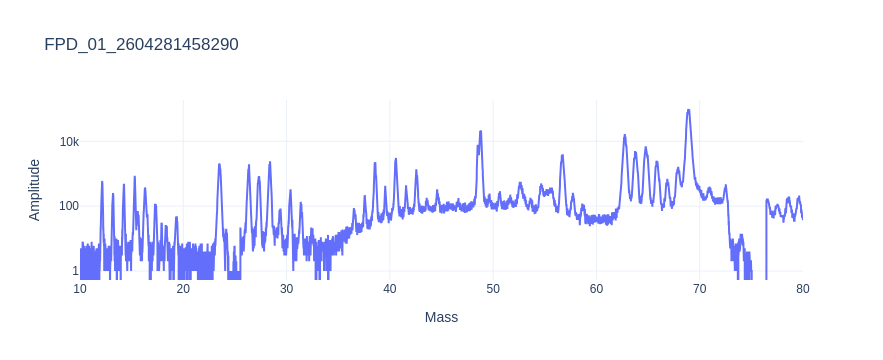

In [19]:
fig = spec.plot_interactive(log_y=True, xlim=(10, 80))
fig

## Interactive peak labels

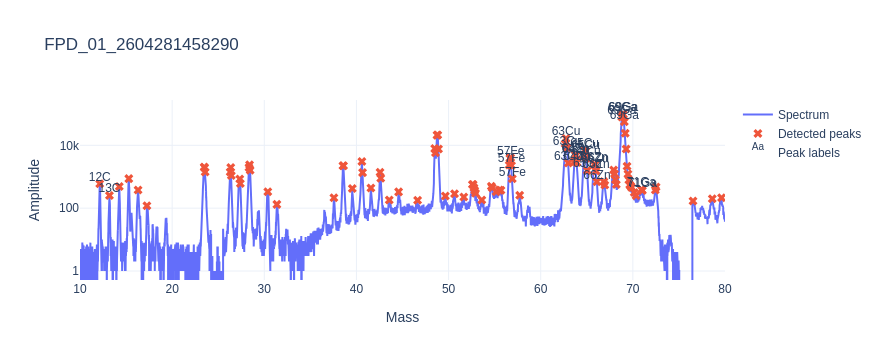

In [20]:
fig, assignments = spec.plot_with_peaks_interactive(
    isotope_table=isotopes,
    tolerance=0.2,
    prominence=100,
    distance=5,
    log_y=True,
    xlim=(10, 80),
)

fig

## Interactive isotope markers

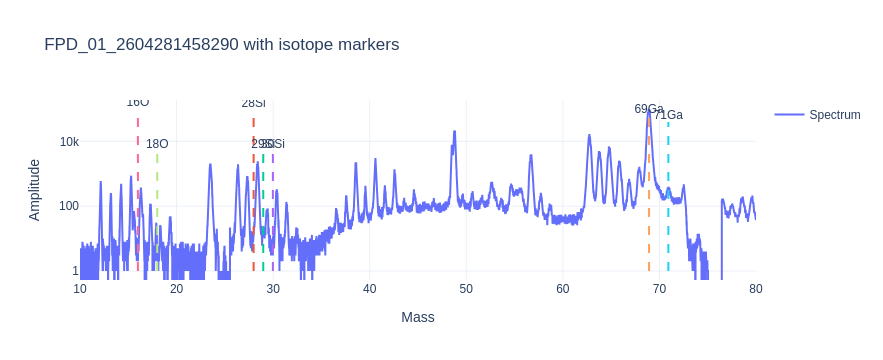

In [21]:
fig = spec.plot_with_element_markers_interactive(
    isotope_table=isotopes,
    elements=["Si", "Ga", "O"],
    log_y=True,
    xlim=(10, 80),
    min_abundance=0.1,
)

fig

## Manual peak binning

In [31]:
bins = manual_peak_binner_interactive(
    spec,
    log_y=True,
    xlim=(20, 40),
)


In [33]:
print(bins)
# After adding bins interactively:
bins.to_dataframe()

ManualPeakBins(bins=[{'label': 'test', 'mass_min': 40.0, 'mass_max': 50.0, 'center_mass': 48.826906, 'max_intensity': 21274.0, 'integrated_intensity': 486112.0, 'n_points': 763}])


,label,mass_min,mass_max,center_mass,max_intensity,integrated_intensity,n_points
0,test,40.0,50.0,48.826906,21274.0,486112.0,763


## Store manually created bins

After adding bins with the manual peak binner widget, save them to a CSV file.
These bins can be reused in the 3D raw image workflow.

Run this cell **after** you have clicked `Add ROI/bin` in the widget above.

In [34]:
from pathlib import Path

BIN_DIR = Path("../data/bins")
BIN_DIR.mkdir(parents=True, exist_ok=True)

manual_bin_file = BIN_DIR / "manual_bins.csv"

# The manual binner returns a ManualPeakBins object.
# It stores clicked bins internally and can export them as a DataFrame.
manual_bins_df = bins.to_dataframe()

display(manual_bins_df)

manual_bins_df.to_csv(manual_bin_file, index=False)

print(f"Saved manual bins to: {manual_bin_file}")

,label,mass_min,mass_max,center_mass,max_intensity,integrated_intensity,n_points
0,test,40.0,50.0,48.826906,21274.0,486112.0,763


Saved manual bins to: ../data/bins/manual_bins.csv


In [35]:
# Optional sanity check: reload the saved manual bins.
manual_bins_reloaded = pd.read_csv(manual_bin_file)
display(manual_bins_reloaded.head())

,label,mass_min,mass_max,center_mass,max_intensity,integrated_intensity,n_points
0,test,40.0,50.0,48.826906,21274.0,486112.0,763
